# NeuroShield AI — SHAP Explainability: Conventional ML

**Model:** HistGradientBoosting  
**Target:** `Ever_told_you_had_a_stroke`

This notebook explains the saved final conventional ML model using SHAP. It creates global feature-importance, beeswarm, dependence, and local waterfall explanations and saves the outputs for the research paper.

> SHAP explains model behavior; it does not establish clinical causation.

In [1]:
# Install once if needed
# %pip install shap joblib pandas numpy matplotlib scikit-learn

In [2]:
import os, re, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

DATA_PATH = "../dataset/processed/transformed_train.csv"
MODEL_PATH = "../models/stroke_model_final.pkl"
FIG_DIR = "../research_figures"
SHAP_DIR = "../models/shap"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(SHAP_DIR, exist_ok=True)

print("SHAP:", shap.__version__)

SHAP: 0.52.0


In [3]:
model = joblib.load(MODEL_PATH)
df = pd.read_csv(DATA_PATH)

TARGET = "ever_told_you_had_a_stroke"
def clean_column_name(col):
    col = re.sub(r'^(binary|multi|ordinal|remainder)__', '', col)
    col = re.sub(r'[^A-Za-z0-9_]+', '_', col)
    col = re.sub(r'_+', '_', col)
    return col.strip('_').lower()
df.columns = [clean_column_name(c) for c in df.columns]
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()


print("Model:", type(model).__name__)
print("X shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Model: HistGradientBoostingClassifier
X shape: (345242, 47)
Target distribution:
ever_told_you_had_a_stroke
0    330571
1     14671
Name: count, dtype: int64


In [4]:
# Reproducible explanation sample
X_shap = X.sample(n=min(5000, len(X)), random_state=42).copy()
print("SHAP sample:", X_shap.shape)

SHAP sample: (5000, 47)


In [5]:
# HistGradientBoosting is a tree-based model, so TreeExplainer is used.
explainer = shap.TreeExplainer(model)
raw_values = explainer.shap_values(X_shap)

if isinstance(raw_values, list):
    raw_values = raw_values[-1]
if hasattr(raw_values, "values"):
    raw_values = raw_values.values
shap_values = np.asarray(raw_values)

print("SHAP values:", shap_values.shape)

SHAP values: (5000, 47)


In [6]:
importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
importance["rank"] = np.arange(1, len(importance) + 1)

display(importance.head(20))
importance.to_csv(f"{SHAP_DIR}/shap_histgradientboosting_feature_importance.csv", index=False)

,feature,mean_abs_shap,rank
0,imputed_age_value_collapsed_above_80,0.534446,1
1,would_you_say_that_in_general_your_health_is,0.307302,2
2,are_you_currently_taking_medicine_prescribed_b...,0.276037,3
3,adults_who_have_been_told_they_have_high_blood...,0.245925,4
4,respondents_that_have_ever_reported_having_cor...,0.173080,5
5,are_you_currently_employed_for_wages,0.137744,6
6,what_is_the_highest_grade_or_year_of_school_yo...,0.075929,7
7,are_you_currently_unable_to_work,0.073646,8
8,is_your_annual_household_income_from_all_sourc...,0.064398,9
9,now_thinking_about_your_physical_health_which_...,0.053026,10


C:\Users\nitya\AppData\Roaming\Python\Python312\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\nitya\AppData\Local\Temp\ipykernel_15988\2374058461.py:3: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


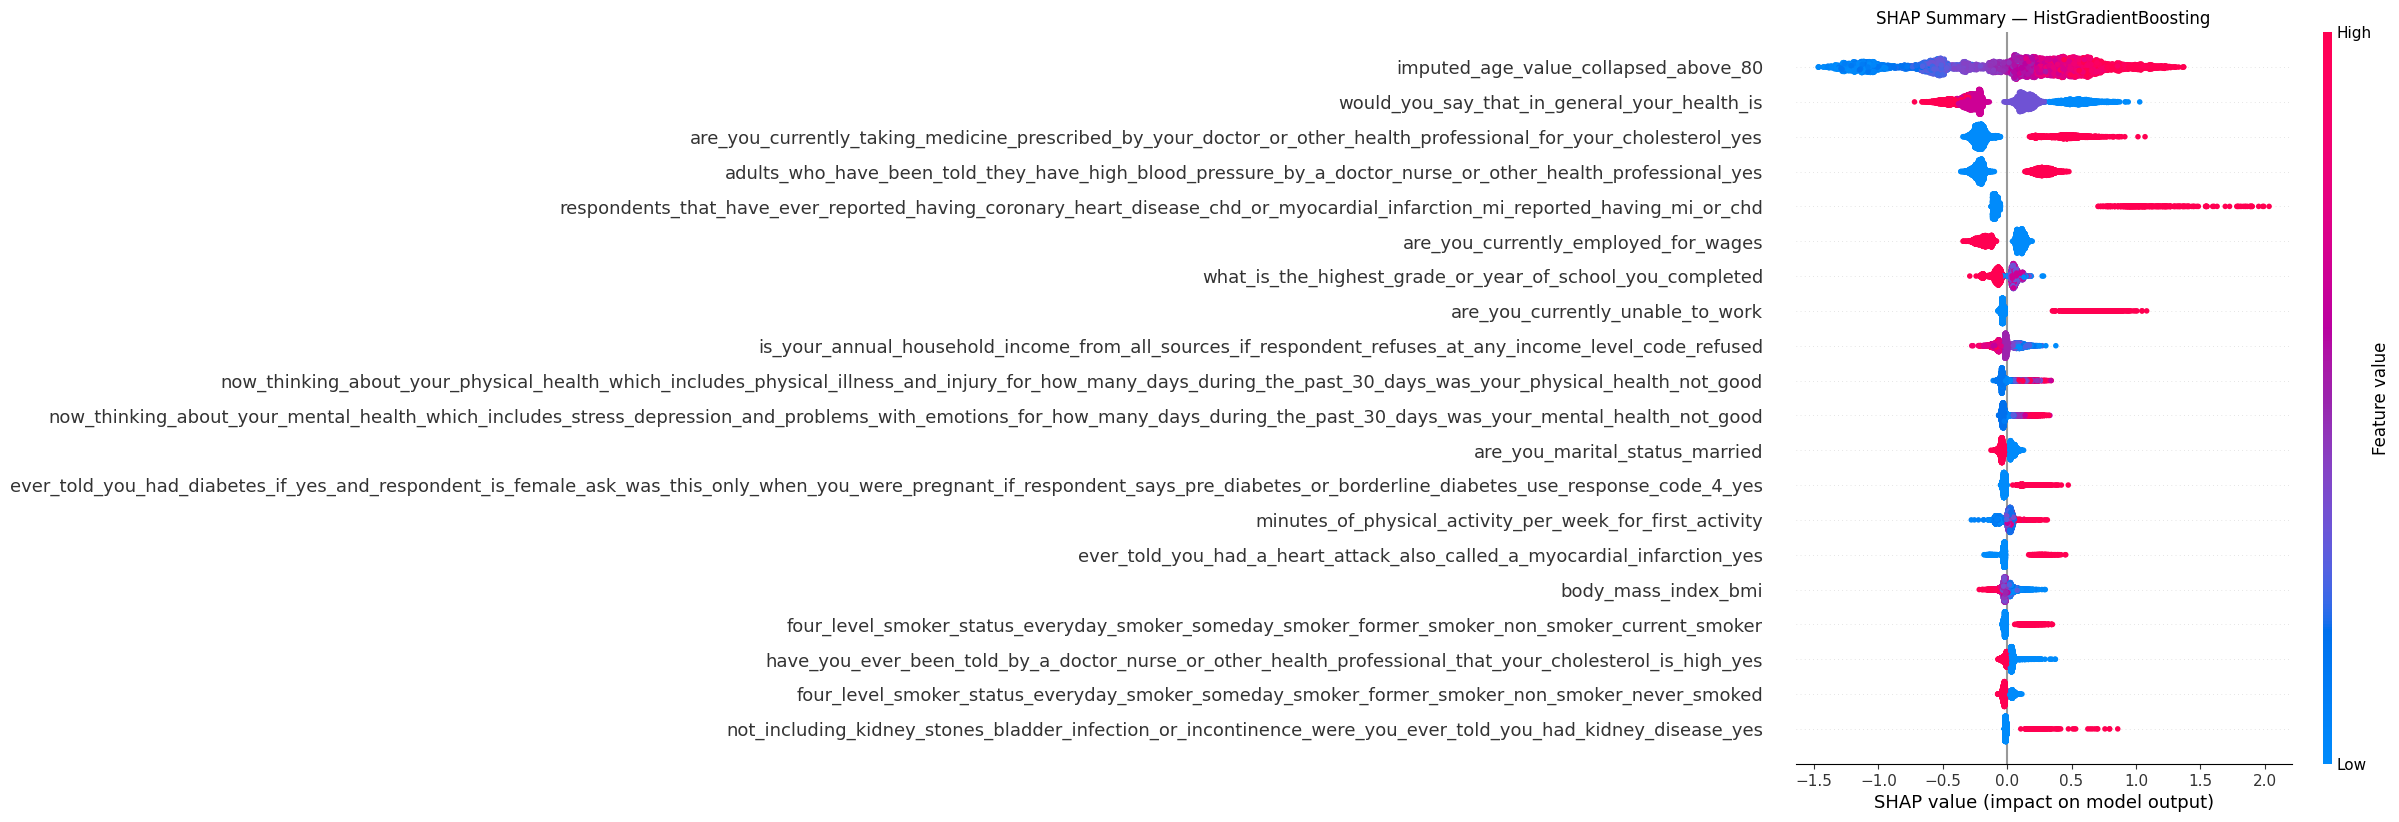

In [7]:
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title("SHAP Summary — HistGradientBoosting")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig10_shap_histgradientboosting_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\nitya\AppData\Roaming\Python\Python312\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\nitya\AppData\Local\Temp\ipykernel_15988\2811241804.py:3: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


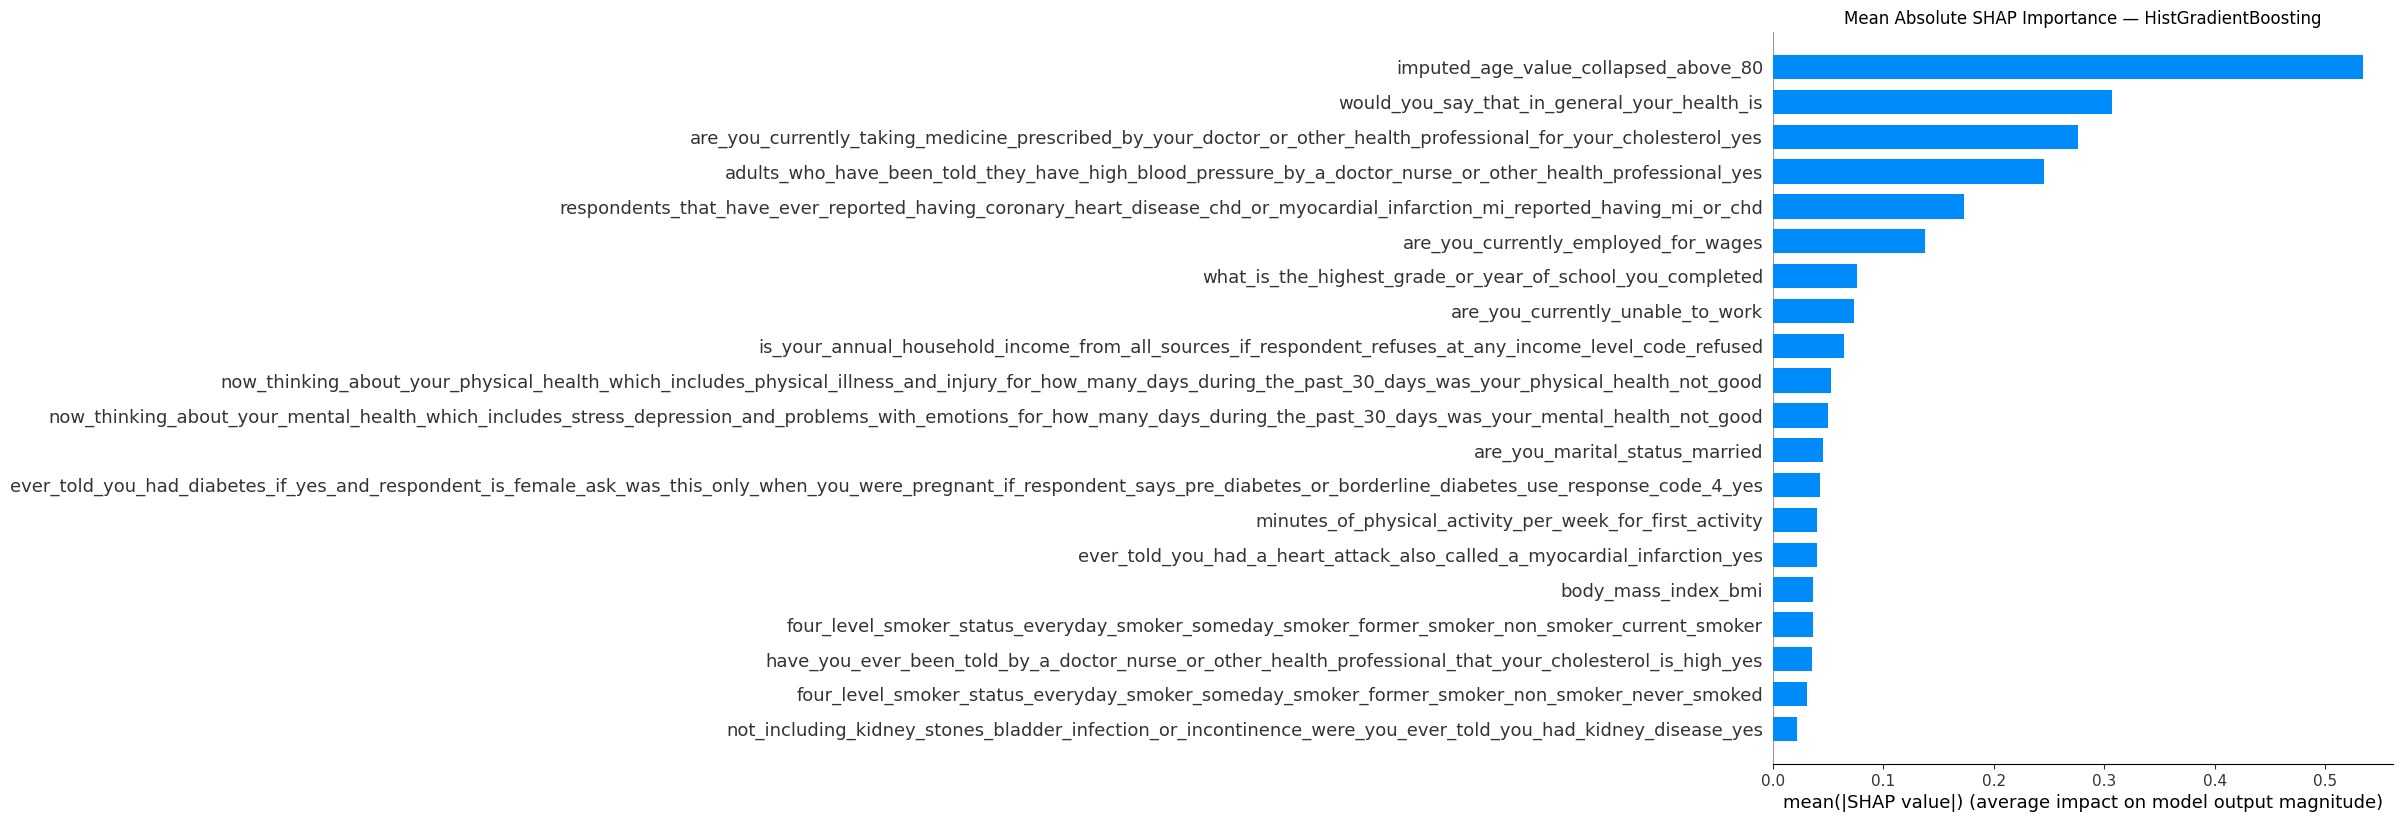

In [8]:
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=20, show=False)
plt.title("Mean Absolute SHAP Importance — HistGradientBoosting")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig11_shap_histgradientboosting_bar.png", dpi=300, bbox_inches="tight")
plt.show()

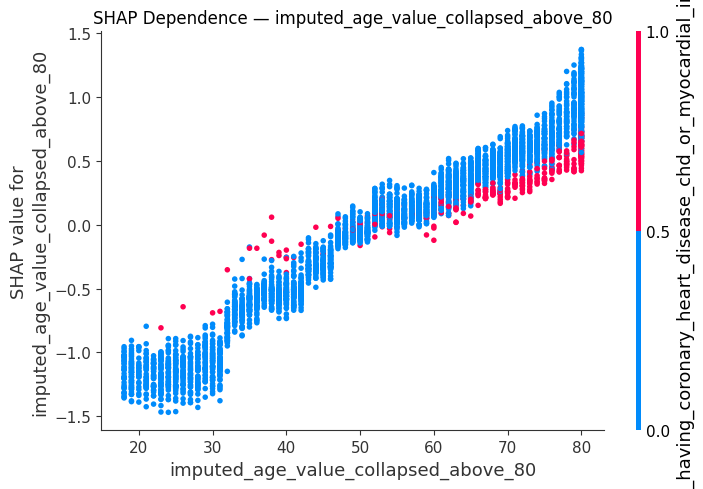

In [9]:
top_feature = importance.iloc[0]["feature"]
shap.dependence_plot(top_feature, shap_values, X_shap, interaction_index="auto", show=False)
plt.title(f"SHAP Dependence — {top_feature}")
plt.tight_layout()
safe = re.sub(r"[^A-Za-z0-9_]+", "_", top_feature)
plt.savefig(f"{FIG_DIR}/fig12_shap_dependence_{safe}.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\nitya\AppData\Local\Temp\ipykernel_15988\3158444251.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


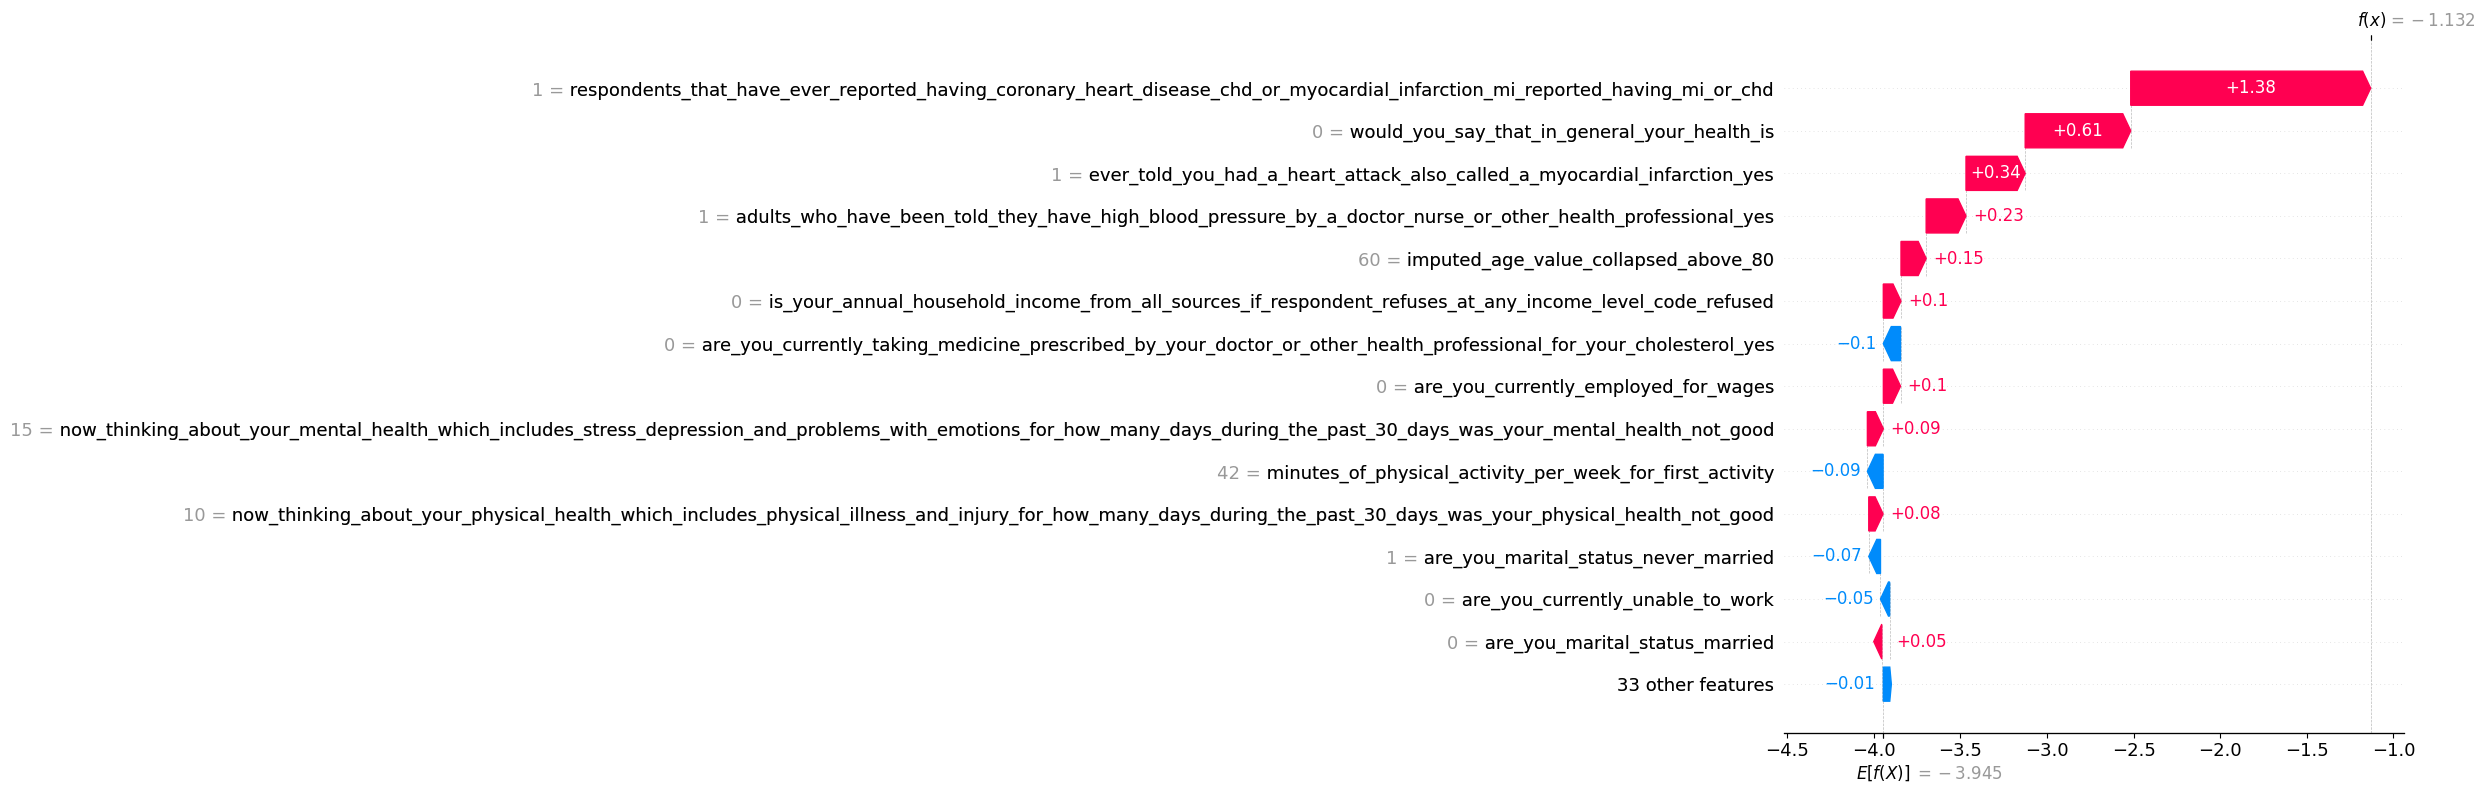

In [10]:
idx = 0
base = explainer.expected_value
if isinstance(base, (list, np.ndarray)):
    base = np.asarray(base).reshape(-1)[-1]

exp = shap.Explanation(
    values=shap_values[idx],
    base_values=base,
    data=X_shap.iloc[idx].values,
    feature_names=X_shap.columns.tolist()
)
shap.plots.waterfall(exp, max_display=15, show=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig13_shap_histgradientboosting_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
pd.DataFrame(shap_values, columns=X_shap.columns).to_csv(
    f"{SHAP_DIR}/shap_histgradientboosting_values.csv", index=False)
X_shap.to_csv(f"{SHAP_DIR}/shap_histgradientboosting_sample.csv", index=False)
print("SHAP outputs saved.")

SHAP outputs saved.


## Research interpretation

Use mean absolute SHAP values for global importance, the beeswarm for direction and magnitude, the dependence plot for feature behavior, and the waterfall for a local prediction.

SHAP values describe contributions to the trained model's output. They should not be presented as causal effects or direct clinical risk percentages.